# Fitting air-density data: choices in mathematical modeling

This notebook uses air density as a convenient data set for studying **mathematical modeling**, rather than atmospheric physics. The central question is not simply, “Can we draw a curve through the points?” Instead, we will examine several choices that must be made before a fit has a well-defined meaning:

1. What functional form should represent the data?
2. What quantity should be minimized?
3. Should every point have equal influence, or should the reported uncertainties determine the weighting?
4. How can residuals reveal behavior hidden by an apparently good graph?

This first notebook fits the density $\rho$ itself. Its companion, `graph_air_density_log.ipynb`, instead fits $\log(\rho)$. Comparing them demonstrates that changing the dependent variable changes the optimization problem, not merely the appearance of the plot.

Set `fit_type` to 1 or 2 to select a model, and set `use_errors` to `False` or `True` to select unweighted or uncertainty-weighted least squares. These two switches provide four modeling choices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

use_errors = False
fit_type = 2

## Choose a fitting function

We will compare two empirical models:

$$f_1(h)=a e^{bh}$$

and

$$f_2(h)=a e^{bh+ch^{3/2}},$$

where $h$ is altitude and $a$, $b$, and $c$ are parameters determined by the fit. The first model has two adjustable parameters. The second has an additional term and therefore more flexibility.

A more flexible model will generally reduce the residual sum of squares, but that fact alone does not prove that it is a better model. Additional parameters can fit genuine structure, noise, or systematic effects. Model comparison therefore requires inspecting residuals and considering the number of fitted parameters, not just looking for the curve that passes closest to the points.

In [2]:
if fit_type == 1:
    def fitfunction(x,a,b):
        return a*np.exp(b*np.array(x))
elif fit_type == 2:
    def fitfunction(x,a,b,c):
        return a*np.exp(b*np.array(x)+c*np.power(np.array(x),1.5))


## Prepare containers for the data

The file contains several atmospheric quantities, but density and altitude are the variables used in this exercise. Separate arrays are created for all columns so the structure of the input file remains explicit.

In [3]:
altitude = []
temp = []
gravity = []
pressure = []
density = []
viscosity = []

## Read and scale the data

Each row of `density.txt` represents one altitude. The density column is tabulated in units of $0.1\;\mathrm{kg/m^3}$, so both density values and their uncertainties must be multiplied by 0.1. Applying the same unit conversion to the data and uncertainties is essential: otherwise the weighting in the fit would be incorrect.

The uncertainty array is supplied for this modeling exercise. When `use_errors=True`, these values are treated as known one-standard-deviation uncertainties, $\sigma_i$. That is a substantive statistical assumption, not simply a plotting option.

In [4]:
npoints = 0
with open('density.txt') as f:
    for line in f:
        npoints=npoints+1
        data = line.split()
        altitude.append(float(data[0]))
        temp.append(float(data[1]))
        gravity.append(float(data[2]))
        pressure.append(float(data[3]))
        # The density column is tabulated in units of 0.1 kg/m^3.
        density.append(0.1*float(data[4]))
        viscosity.append(float(data[5]))
        

In [5]:

if use_errors == True:
    # create a list to hold the uncertainty in the density  
    density_uncertainty = [0.01,0.01,0.01,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.0001,0.0001,0.0001,0.00001,0.00001,0.000001,0.0000001,0.0000001]
else:
    density_uncertainty = [0.0]*len(density)
    
# Convert the tabulated density uncertainties to kg/m^3 as well.
density_uncertainty = 0.1*np.array(density_uncertainty)

Text(0, 0.5, 'Density (kg/m^3)')

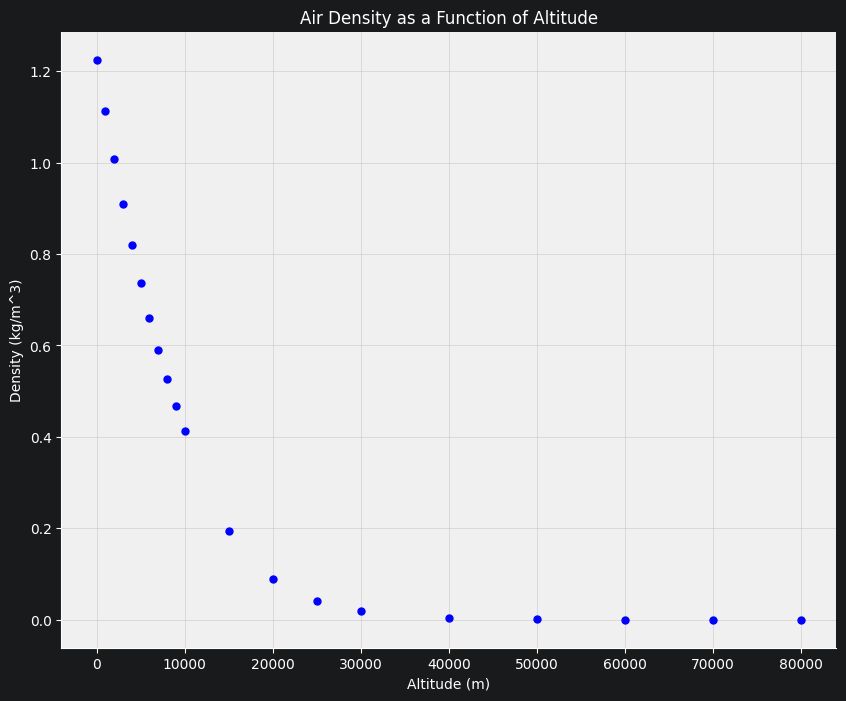

In [6]:
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Set the grid lines
ax.grid(True)

# Set the background color
ax.set_facecolor('#F0F0F0')

# Set the border properties
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the line and marker properties
line_color = 'b'
line_width = 0
marker_color = 'b'
marker_style = 'o'
marker_size = 5

# Create the plot
if use_errors == True:
    plt.errorbar(altitude, density, yerr=density_uncertainty, color=line_color, linewidth=line_width,
         marker=marker_style, markersize=marker_size, markerfacecolor=marker_color, capsize=10)
else:
    plt.plot(altitude, density, color=line_color, linewidth=line_width,
         marker=marker_style, markersize=marker_size, markerfacecolor=marker_color)

# Set the plot title and axis labels
plt.title("Air Density as a Function of Altitude")
plt.xlabel("Altitude (m)")
plt.ylabel("Density (kg/m^3)")
#plt.yscale("log")

## Fit the density values

`scipy.optimize.curve_fit` adjusts the model parameters to minimize a least-squares objective. With `use_errors=False`, every point is weighted equally and the minimized quantity is

$$S=\sum_i [\rho_i-f(h_i)]^2.$$

Because these are **absolute** density residuals, points with large density values can dominate $S$. A residual of $0.01\;\mathrm{kg/m^3}$ has the same cost at every altitude, even though it may be a tiny fractional error for one point and a very large fractional error for another.

With `use_errors=True`, the minimized quantity is the chi-square statistic

$$\chi^2=\sum_i\left[\frac{\rho_i-f(h_i)}{\sigma_i}\right]^2.$$

A point with a smaller uncertainty receives more weight because a given residual represents more standard deviations. `absolute_sigma=True` tells `curve_fit` to interpret the supplied $\sigma_i$ values as absolute uncertainties when estimating the parameter covariance matrix. The diagonal entries of that matrix are the parameter variances; their square roots are the estimated parameter standard deviations. Off-diagonal entries describe correlations between fitted parameters.

The initial parameter values (`p0`) give the nonlinear optimizer a starting point. A nonlinear fit can sometimes converge to different solutions, or fail to converge, when the starting values are poor.

In [7]:
from scipy.optimize import curve_fit

if fit_type == 1:
    init_vals = [1.2,-0.0001]
elif fit_type == 2:
    init_vals = [1.2,-0.0001, -0.000001]

if use_errors == False:
    popt, pcov = curve_fit(fitfunction, altitude, density, p0=init_vals)
else:
    popt, pcov = curve_fit(fitfunction, altitude, density, sigma=density_uncertainty, absolute_sigma=True, p0=init_vals)

print (popt)
print (pcov)

[ 1.21440951e+00 -7.36616443e-05 -3.64764693e-07]
[[ 2.96111130e-05 -1.28999954e-08  1.01964242e-10]
 [-1.28999954e-08  1.09584680e-11 -1.02464559e-13]
 [ 1.01964242e-10 -1.02464559e-13  1.02438698e-15]]


## Quantify the residuals

The residual for point $i$ is $r_i=\rho_i-f(h_i)$. For the weighted fit, the code reports $\chi^2$ and the number of degrees of freedom,

$$\nu=N-p,$$

where $N$ is the number of data points and $p$ is the number of fitted parameters. If the model is appropriate, the uncertainties are realistic and independent, and the usual statistical assumptions apply, one often expects the reduced chi-square $\chi^2/\nu$ to be of order one. A value much larger than one can indicate an inadequate model, underestimated uncertainties, correlations, or some combination of these. A value much smaller than one can indicate overestimated uncertainties or correlated data.

When uncertainties are not used, the code accumulates the unweighted sum of squared residuals. Although the variable and printed label use the name `chi2`, this unweighted quantity is **not a statistical chi-square** because the residuals have not been divided by uncertainties. Its numerical scale also carries units, so it should not be interpreted using reduced-chi-square rules.

In [8]:
yfit = []
chi2=0

if use_errors == False:
    for i in range (0,npoints):
        yfit.append(fitfunction(altitude[i],*popt))
        chi2 += (density[i]-yfit[i])**2
else:
    for i in range (0,npoints):
        yfit.append(fitfunction(altitude[i],*popt))
        chi2 += ((density[i]-yfit[i])/density_uncertainty[i])**2

print ("Chi^2 / dof = %.3E / %d" % (chi2,npoints-len(init_vals)))

Chi^2 / dof = 7.711E-04 / 17


## Plot the fit

The data and fitted model are shown together on a logarithmic vertical axis so that values spanning many orders of magnitude remain visible. This changes only the visualization: the fit above was still performed using $\rho$, not $\log(\rho)$. A log-scale plot and a log-space fit are mathematically different operations.

The plots that follow show both percentage residuals and absolute residuals. Absolute residuals match the quantity minimized by the unweighted density fit. Percentage residuals answer a different question—how large the discrepancy is relative to the measured value—and are often more revealing when the dependent variable spans a large dynamic range. Residuals should fluctuate without a systematic pattern if the model captures the trend adequately; curvature or long runs of the same sign suggest missing structure.

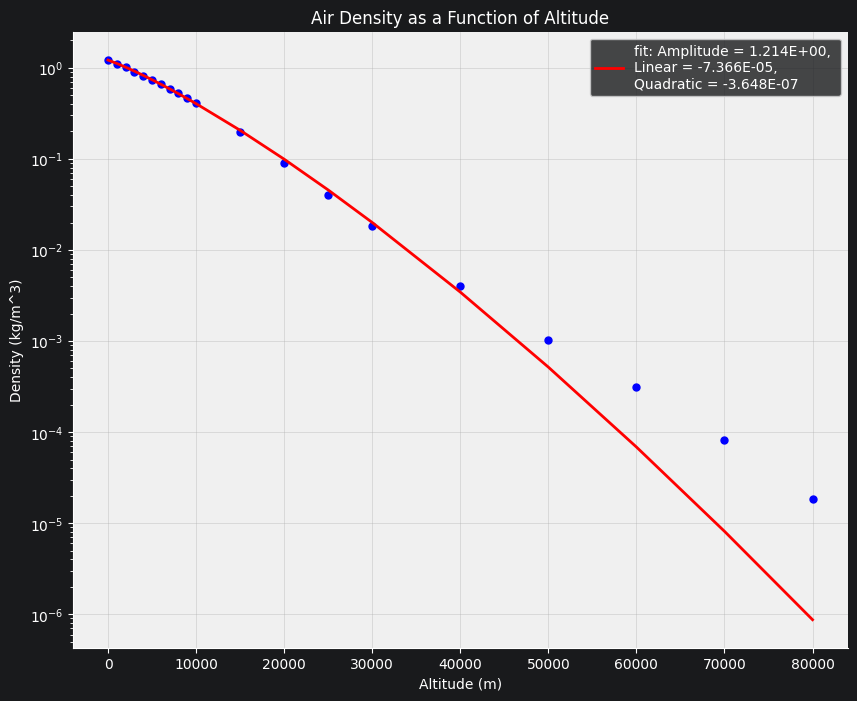

In [13]:
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Set the grid lines
ax.grid(True)

# Set the background color
ax.set_facecolor('#F0F0F0')

# Set the border properties
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the line and marker properties
line_color = 'b'
line_width = 0
marker_color = 'b'
marker_style = 'o'
marker_size = 5

# Create the plot
if use_errors == True:
    plt.errorbar(altitude, density, yerr=density_uncertainty, color=line_color, linewidth=line_width,
         marker=marker_style, markersize=marker_size, markerfacecolor=marker_color, capsize=10)
else:
    plt.plot(altitude, density, color=line_color, linewidth=line_width,
         marker=marker_style, markersize=marker_size, markerfacecolor=marker_color)

if fit_type == 1:
    plt.plot(altitude,yfit,color='r', linewidth=2, label =
    'fit: Amplitude = %.3E, \nLinear = %.3E' % tuple(popt))
else:
    plt.plot(altitude,yfit,color='r', linewidth=2, label =
    'fit: Amplitude = %.3E, \nLinear = %.3E, \nQuadratic = %.3E' % tuple(popt))

# Set the plot title and axis labels
plt.title("Air Density as a Function of Altitude")
plt.xlabel("Altitude (m)")
plt.ylabel("Density (kg/m^3)")
plt.yscale("log")
plt.legend()

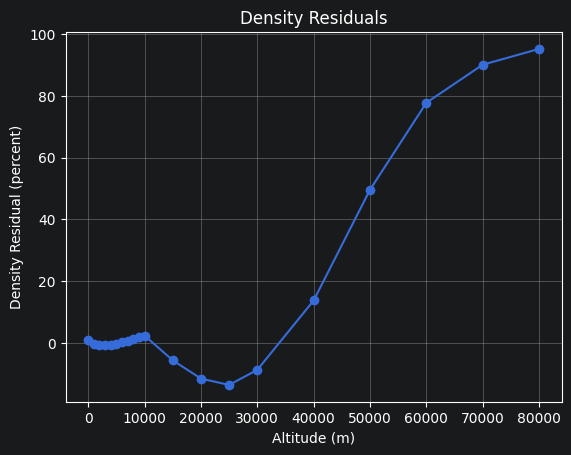

In [10]:
plt.title("Density Residuals")
plt.xlabel('Altitude (m)')
plt.ylabel('Density Residual (percent)')
plt.grid(True)

plt.plot(altitude, (density - fitfunction(altitude, *popt))/density*100, 'o-')

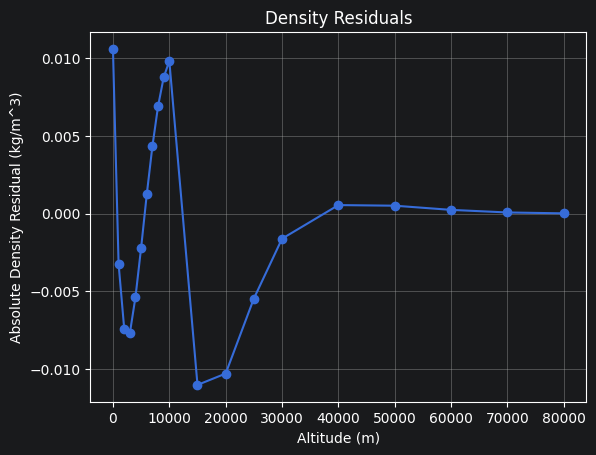

In [11]:
plt.title("Density Residuals")
plt.xlabel('Altitude (m)')
plt.ylabel('Absolute Density Residual (kg/m^3)')
plt.grid(True)

plt.plot(altitude, (density - fitfunction(altitude, *popt)), 'o-')

## Modeling lessons

There is no fitting procedure that is independent of modeling choices. In this notebook:

- Choosing $f_1$ or $f_2$ determines which shapes the optimizer is allowed to consider.
- Omitting uncertainties minimizes absolute squared density residuals with equal point weights.
- Including uncertainties minimizes squared residuals measured in units of each point's uncertainty.
- Adding a parameter can improve the numerical fit without guaranteeing a more meaningful model.
- A logarithmic plotting axis does not change the quantity that was minimized.

The parameter estimates, covariance matrix, objective-function value, and residual plots provide complementary information. None of them should be treated as a complete assessment by itself. The companion log-density notebook changes the objective function and provides a direct demonstration of how that choice changes the result.